# Behavioural analysis

All the analysis code lives in the `ppsanalysis` package. This notebook only
**drives** it: load the data, build the shared tables, run each hypothesis, read
the results.

```
ppsanalysis/
  config.py        paths, subject metadata, RT window, seeds, thresholds
  figures.py       publication-grade SVG settings and helpers
  io.py            Unity export loading and tidying
  qc.py            trial usability and data-quality checks
  stats_utils.py   sigmoid/AIC fits, bootstrap, permutation, classification
  pps.py           facilitation, near-far index, sigmoid boundary, Delta_PPS
  collision.py     PSE, Delta_coll, carryover, accuracy
  permutations.py  label-shuffling nulls for the single-case tests
  tables.py        the shared derived tables, built once
  hypotheses/
    h1  h1a  h2  h3  h4     Aim 1, young controls
    h5  h6   h6b  h7        Aim 2, the patient
    h8a h8b                 Aim 3, PPS and Hit-or-Miss together
```

Every hypothesis module has a `run(t)` function, a `report()` that prints the
numbers, and a `make_figure()` that draws them. Open any of them and read it
top to bottom: they are written as a sequence of numbered steps, and each step
says why it is there.

**Figures.** Every figure is saved as an editable SVG (and a PDF) in `figures/`.
They are drawn at real journal column width, so the font sizes are already correct
and you must not resize them afterwards.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import style
style.apply()

import ppsanalysis as pa
from ppsanalysis import config, figures
from ppsanalysis.hypotheses import h1, h1a, h2, h3, h4, h5, h6, h6b, h7, h8a, h8b

# Publication-grade defaults: vector SVG, editable text, bold titles,
# journal-sized fonts, no top/right frame lines.
figures.apply()
figures.FIGURE_DIR = "figures"

pd.set_option("display.max_columns", 120)

## 0.1 Configuration

Everything the analysis depends on is in `ppsanalysis/config.py`. Override it here.

Two settings deserve attention:

**`RT_MAX_MS` is now 1000, not 3000.** The old ceiling was longer than an entire
fast trial, so it let in presses made near the *end* of a trial as if they were
detections. Petrizzo et al. (2024) excluded RTs above 1000 ms on this exact task
and reported mean RTs of 250 to 320 ms.

**`DROP_POSITIONS` excludes distance levels entirely.** Dropping one is a
preregistration deviation. Leave it empty unless you have a stated reason.

In [2]:
config.PILOT_DATA_DIR = "/Users/pamelavandenenden/Desktop/PPS/05_analysis/data/behavior"
config.OUT_DIR = "."

config.RT_MIN_MS = 100
config.RT_MAX_MS = 900
config.DROP_POSITIONS = ()         

config.YOUNG_CONTROL_SUBJECTS = ["theo", "franc"]
config.PATIENT_ID = ["pam"]
config.MATCHED_CONTROL_ID = None

config.N_BOOT = 5000
config.RANDOM_SEED = 123

## 1. Load the data and build the shared tables

In [3]:
pps_trials, collision_trials, subjects = pa.io.make_analysis_csvs(
    data_dir=config.PILOT_DATA_DIR,
    out_dir=config.OUT_DIR,
)

pps_trials = pa.qc.mark_pps_usable(
    pps_trials,
    rt_min_ms=config.RT_MIN_MS,
    rt_max_ms=config.RT_MAX_MS,
    drop_positions=config.DROP_POSITIONS,
)

t = pa.tables.build(pps_trials, collision_trials, subjects)
pa.tables.describe(t)

Trial files found: 7
 - sub-franc-task2_session-1_task2_trials.csv | folder: franc-task2_s1
 - sub-franc_session-1_task1_trials.csv | folder: franc_s1
 - sub-pam2-task2_session-1_task2_trials.csv | folder: pam2-task2_s1
 - sub-pam_session-1_task2_trials.csv | folder: pam_s1-task2
 - sub-pam_session-1_task1_trials.csv | folder: pam_s1
 - sub-theo_session-1_task2_trials.csv | folder: theo_s1-task2
 - sub-theo_session-1_task1_trials.csv | folder: theo_s1
Loaded from:  /Users/pamelavandenenden/Desktop/PPS/05_analysis/data/behavior
Saved CSVs to: .
PPS trials       :  1344  (685 usable)
Collision trials :   538  (538 usable)
Young controls   : ['franc', 'theo']
RT window        : 100-900 ms
Dropped positions: none
Clinical pair    : patient=pam, control=franc


## 1.1 Data quality

In [4]:
pa.qc.quick_qc(t.pps_trials, t.collision_trials)

,dataset,rows,usable,excluded,usable_%
0,PPS,1344,685,659,51.0
1,Hit/Miss,538,538,0,100.0


=== PPS trial counts ===
saved: figures/quick_qc/pps_trial_counts_by_condition_fast.png


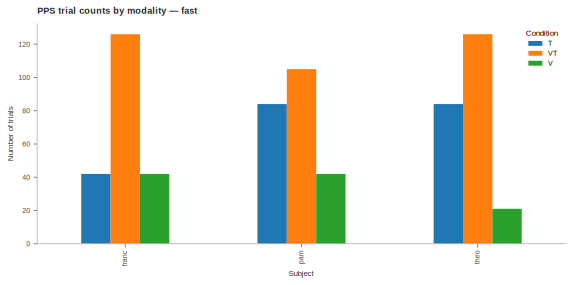

saved: figures/quick_qc/pps_trial_counts_by_condition_slow.png


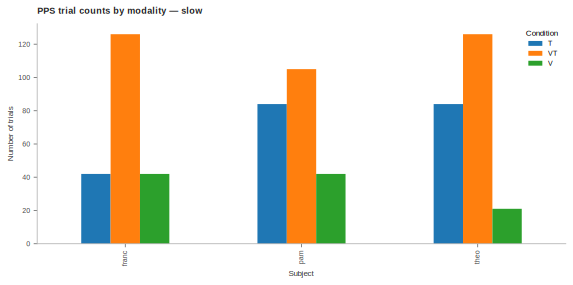

subject speed sensory_condition   n
  franc  fast                 T  42
  franc  fast                 V  42
  franc  fast                VT 126
  franc  slow                 T  42
  franc  slow                 V  42
  franc  slow                VT 126
    pam  fast                 T  84
    pam  fast                 V  42
    pam  fast                VT 105
    pam  slow                 T  84
    pam  slow                 V  42
    pam  slow                VT 105
   theo  fast                 T  84
   theo  fast                 V  21
   theo  fast                VT 126
   theo  slow                 T  84
   theo  slow                 V  21
   theo  slow                VT 126

=== PPS response rate ===
saved: figures/quick_qc/pps_response_rate_T.png


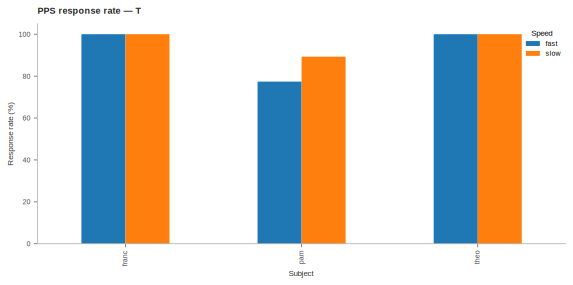

saved: figures/quick_qc/pps_response_rate_VT.png


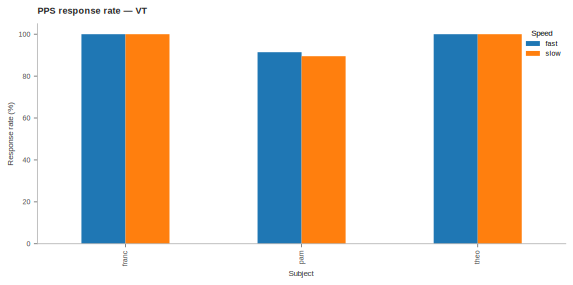

saved: figures/quick_qc/pps_response_rate_V.png


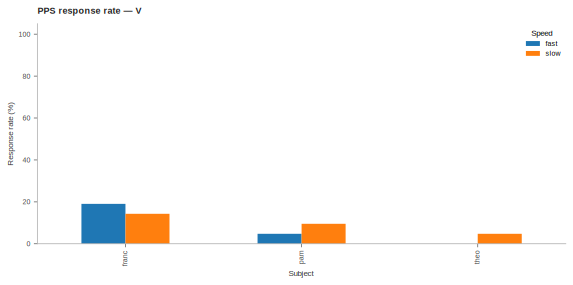

subject speed sensory_condition   n  response_rate  response_rate_percent
  franc  fast                 T  42           1.00                 100.00
  franc  fast                 V  42           0.19                  19.05
  franc  fast                VT 126           1.00                 100.00
  franc  slow                 T  42           1.00                 100.00
  franc  slow                 V  42           0.14                  14.29
  franc  slow                VT 126           1.00                 100.00
    pam  fast                 T  84           0.77                  77.38
    pam  fast                 V  42           0.05                   4.76
    pam  fast                VT 105           0.91                  91.43
    pam  slow                 T  84           0.89                  89.29
    pam  slow                 V  42           0.10                   9.52
    pam  slow                VT 105           0.90                  89.52
   theo  fast                 T  84   

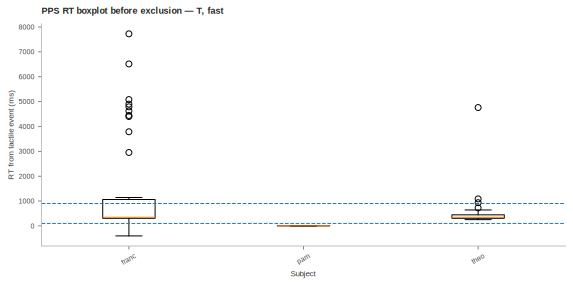

saved: figures/quick_qc/pps_rt_boxplot_T_slow.png


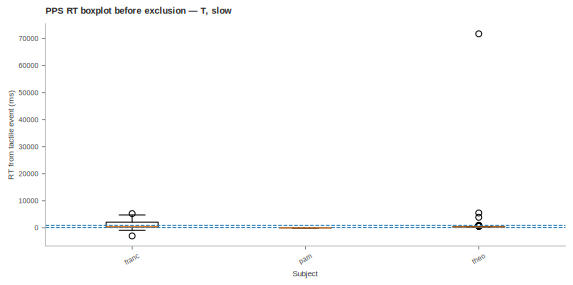

saved: figures/quick_qc/pps_rt_boxplot_VT_fast.png


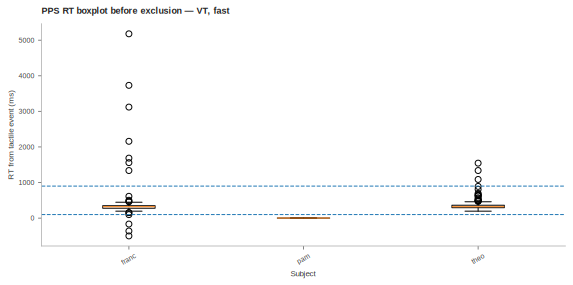

saved: figures/quick_qc/pps_rt_boxplot_VT_slow.png


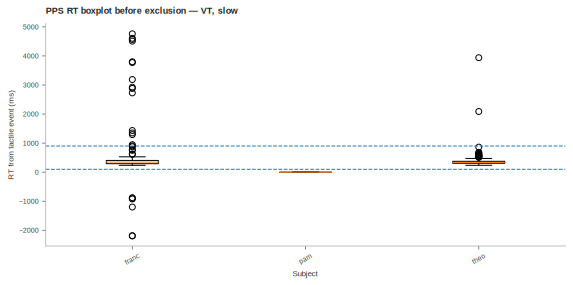

subject speed sensory_condition   n  median_rt  mean_rt   min_rt   max_rt
  franc  fast                 T  42     348.30  1437.31  -403.60  7726.10
  franc  fast                VT 126     320.10   430.98  -500.80  5179.20
  franc  slow                 T  42     404.10  1286.64 -2993.00  5262.50
  franc  slow                VT 126     347.75   580.27 -2192.40  4761.30
    pam  fast                 T  84       1.70     1.70     0.15     3.25
    pam  fast                VT 105       1.70     1.70     0.15     3.25
    pam  slow                 T  84       1.70     1.70     0.15     3.25
    pam  slow                VT 105       1.70     1.70     0.15     3.25
   theo  fast                 T  84     347.85   444.38   250.50  4761.10
   theo  fast                VT 126     320.15   372.26   194.90  1544.80
   theo  slow                 T  84     348.15  1336.87   250.70 71754.50
   theo  slow                VT 126     334.30   408.55   236.90  3939.80

=== Hit/Miss trial counts ===
saved: 

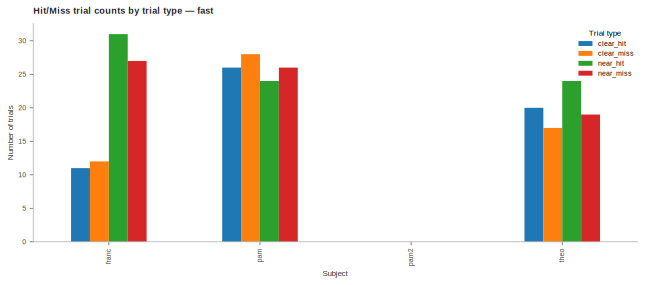

saved: figures/quick_qc/collision_trial_counts_by_type_slow.png


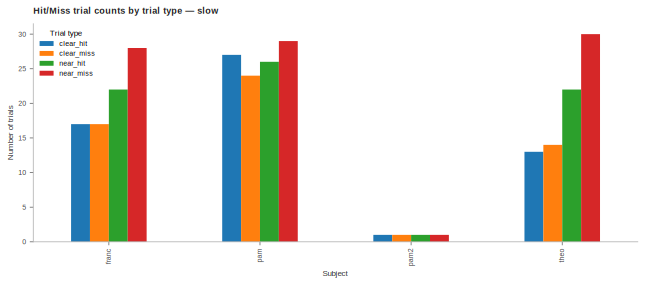

subject speed trial_type  n
  franc  fast  clear_hit 11
  franc  fast clear_miss 12
  franc  fast   near_hit 31
  franc  fast  near_miss 27
  franc  slow  clear_hit 17
  franc  slow clear_miss 17
  franc  slow   near_hit 22
  franc  slow  near_miss 28
    pam  fast  clear_hit 26
    pam  fast clear_miss 28
    pam  fast   near_hit 24
    pam  fast  near_miss 26
    pam  slow  clear_hit 27
    pam  slow clear_miss 24
    pam  slow   near_hit 26
    pam  slow  near_miss 29
   pam2  slow  clear_hit  1
   pam2  slow clear_miss  1
   pam2  slow   near_hit  1
   pam2  slow  near_miss  1
   theo  fast  clear_hit 20
   theo  fast clear_miss 17
   theo  fast   near_hit 24
   theo  fast  near_miss 19
   theo  slow  clear_hit 13
   theo  slow clear_miss 14
   theo  slow   near_hit 22
   theo  slow  near_miss 30

=== Hit/Miss accuracy ===
saved: figures/quick_qc/collision_accuracy_by_trial_type_fast.png


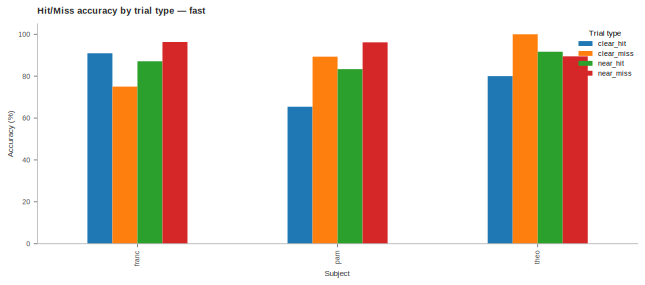

saved: figures/quick_qc/collision_accuracy_by_trial_type_slow.png


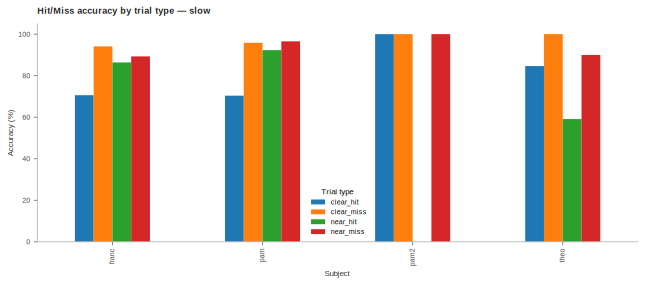

subject speed trial_type  n  accuracy  accuracy_percent
  franc  fast  clear_hit 11      0.91             90.91
  franc  fast clear_miss 12      0.75             75.00
  franc  fast   near_hit 31      0.87             87.10
  franc  fast  near_miss 27      0.96             96.30
  franc  slow  clear_hit 17      0.71             70.59
  franc  slow clear_miss 17      0.94             94.12
  franc  slow   near_hit 22      0.86             86.36
  franc  slow  near_miss 28      0.89             89.29
    pam  fast  clear_hit 26      0.65             65.38
    pam  fast clear_miss 28      0.89             89.29
    pam  fast   near_hit 24      0.83             83.33
    pam  fast  near_miss 26      0.96             96.15
    pam  slow  clear_hit 27      0.70             70.37
    pam  slow clear_miss 24      0.96             95.83
    pam  slow   near_hit 26      0.92             92.31
    pam  slow  near_miss 29      0.97             96.55
   pam2  slow  clear_hit  1      1.00           

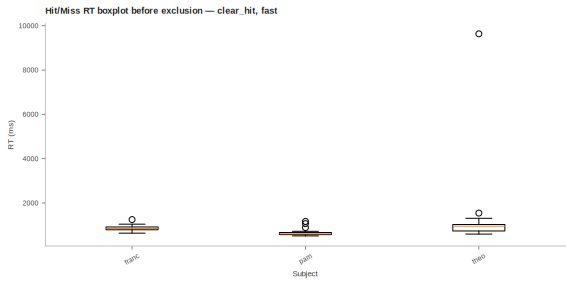

saved: figures/quick_qc/collision_rt_boxplot_clear_miss_fast.png


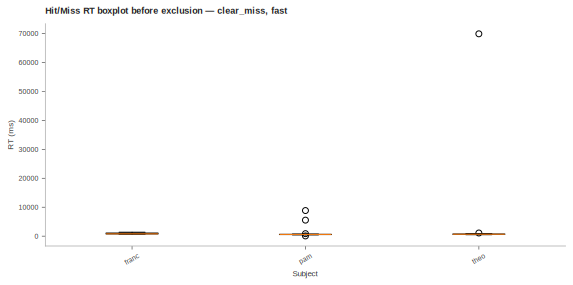

saved: figures/quick_qc/collision_rt_boxplot_near_hit_fast.png


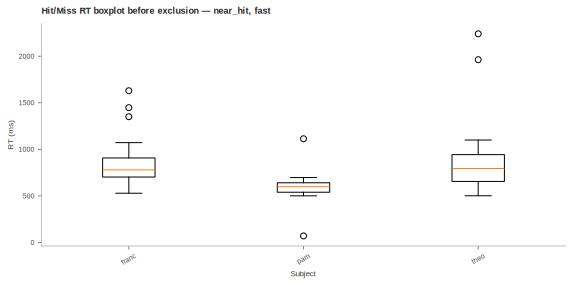

saved: figures/quick_qc/collision_rt_boxplot_near_miss_fast.png


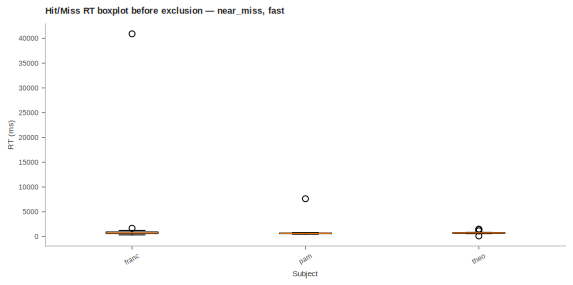

saved: figures/quick_qc/collision_rt_boxplot_clear_hit_slow.png


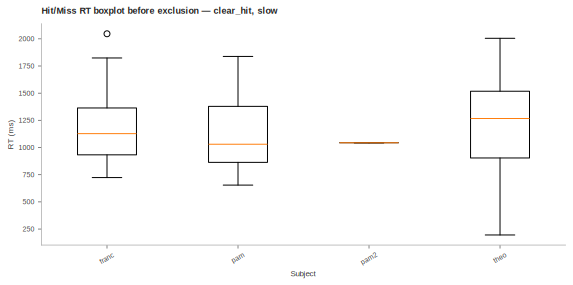

saved: figures/quick_qc/collision_rt_boxplot_clear_miss_slow.png


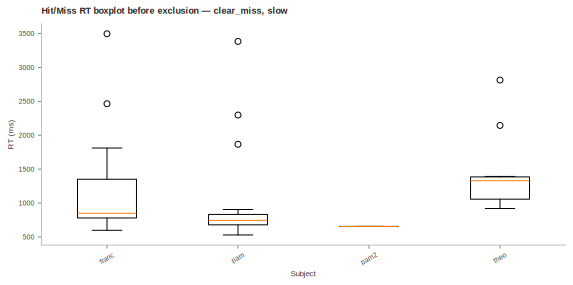

saved: figures/quick_qc/collision_rt_boxplot_near_hit_slow.png


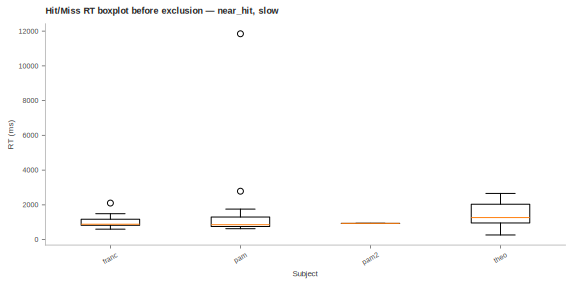

saved: figures/quick_qc/collision_rt_boxplot_near_miss_slow.png


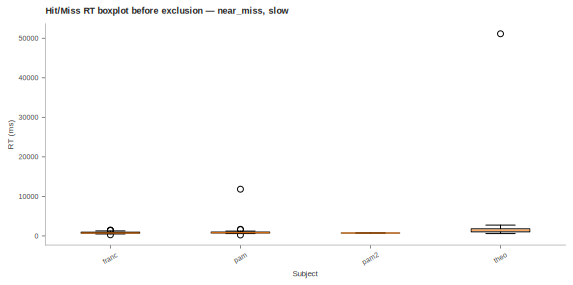

subject speed trial_type  n  median_rt  mean_rt  min_rt   max_rt
  franc  fast  clear_hit 11     850.30   874.56  640.34  1252.59
  franc  fast clear_miss 12     815.38   934.15  696.07  1364.53
  franc  fast   near_hit 31     779.42   840.92  528.70  1629.47
  franc  fast  near_miss 27     724.19  2280.20  334.43 40915.58
  franc  slow  clear_hit 17    1127.97  1221.14  723.61  2046.56
  franc  slow clear_miss 17     849.32  1208.15  598.58  3495.75
  franc  slow   near_hit 22     883.98   999.42  598.87  2102.42
  franc  slow  near_miss 28     751.66   846.86  278.32  1461.88
    pam  fast  clear_hit 26     612.29   661.25  514.75  1169.07
    pam  fast clear_miss 28     605.60  1057.66   97.40  8868.55
    pam  fast   near_hit 24     598.70   596.99   70.07  1113.48
    pam  fast  near_miss 26     640.72   909.81  473.49  7628.94
    pam  slow  clear_hit 27    1030.25  1144.77  654.22  1838.08
    pam  slow clear_miss 24     744.82   950.24  529.06  3383.13
    pam  slow   near_hit 

In [13]:
from ppsanalysis import quick_behavior_plots as qbp

quick_qc = qbp.run(
    t,
    rt_min=config.RT_MIN_MS,
    rt_max=config.RT_MAX_MS,
    save_dir="figures/quick_qc",
    show=True,
)

# Aim 1 — The PPS effect in young healthy controls

## H1. Facilitation increases as the stimulus approaches

Supported if the bootstrap 95% CI on the near-far index lies entirely above zero.

H1, step 1: facilitation (ms) at each distance
  rows = distance rank, 1 = closest to the body
  positive = the visual stimulus made the person faster

subject        franc  theo
position_rank             
1.0              3.9  17.1
2.0             79.8   0.0
3.0             13.3  20.8
4.0            -13.7   6.9
5.0            -14.3  35.0
6.0             34.8  14.1
7.0              NaN  49.2

H1, step 2: near-far index per participant
  near = D1 and D2, far = D6 and D7

subject  near_mean  far_mean  nearfar_pps
  franc      41.81     10.20        31.61
   theo       8.55     31.66       -23.11

H1, step 3: group test on the near-far index
  number of participants  = 2
  mean NearFar_PPS        = 4.25 ms
  bootstrap 95% CI        = [-23.11, 31.61] ms
  Wilcoxon (one-sided)    = W 2.0, p 0.5000

  The bootstrap CI decides support. The Wilcoxon is a sensitivity check only.

  H1 is NOT supported: the 95% CI includes zero.
  saved: figures/h1_facilitation.svg
  saved: figures/h1_facilitat

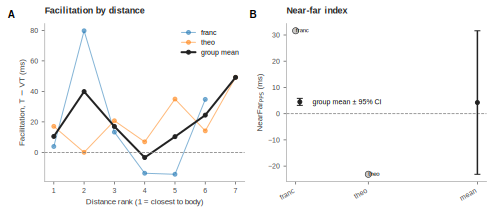

In [5]:
r_h1 = h1.run(t)

## H1a. The facilitation profile is sigmoidal

A sigmoid implies a *boundary*. A straight line does not. This compares flat,
linear and sigmoid fits by AIC.

Distance ranks present in the data: 1 to 7

H1a: model comparison for each participant
  lower AIC = better fit

subject  aic_flat  aic_linear  aic_sigmoid  x_c     k preferred  sigmoid_lower_aic
  franc     62.83       64.49        66.70 2.96 21.43      flat              False
   theo     62.27       60.61        63.79 4.51 26.11      flat              False

H1a: group-averaged profile (descriptive)

aic_flat        63.445
aic_linear      64.627
aic_sigmoid     64.622
x_c              6.015
k              -64.724
preferred         flat

H1a verdict (preregistered criterion):
  sigmoid AIC lower than BOTH flat and linear in 0 of 2 participants

H1a extra (stricter, descriptive):
  sigmoid also wins by a margin of 2.0, with a boundary
  inside the tested range, in 0 of 2 participants
  saved: figures/h1a_sigmoid_shape.svg
  saved: figures/h1a_sigmoid_shape.pdf


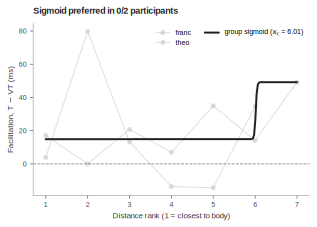

In [6]:
r_h1a = h1a.run(t)

## H2. The PPS boundary moves outward for faster approach

Note that H2 refuses to draw a sigmoid whose inflection falls outside the tested
range, or whose slope is implausible. If it says the fit was rejected, then
Delta_PPS is not measuring a boundary shift and H2 cannot be interpreted.

H2, step 1: Delta_PPS per participant
  Delta_PPS = x_c(fast) - x_c(slow). Positive = boundary moved outward.

subject  delta_pps
  franc      0.417
   theo     -1.022

H2, step 2: group test
  number of participants  = 2
  mean Delta_PPS          = -0.302
  bootstrap 95% CI        = [-1.022, 0.417]
  Wilcoxon (one-sided)    = W 1.0, p 0.7500

  H2 is NOT supported.

  A rejected fit means the boundary fell outside the tested range, or the
  slope was implausible. If this happens, Delta_PPS is not measuring a
  boundary shift, and H2 cannot be interpreted. Check the raw profile.
  saved: figures/h2_delta_pps.svg
  saved: figures/h2_delta_pps.pdf


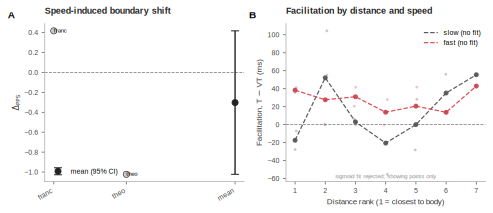

In [7]:
r_h2 = h2.run(t)

## H3. The collision boundary shifts with ball speed

H3, step 1: Delta_coll per participant
  Delta_coll = PSE(fast) - PSE(slow), in cm.
  Positive = the collision boundary moved outward for a fast ball.

subject  delta_coll
  franc        2.46
   theo      -12.08

H3, step 2: group test
  number of participants  = 2
  mean Delta_coll         = -4.81 cm
  bootstrap 95% CI        = [-12.08, 2.46] cm
  Wilcoxon (one-sided)    = W 1.0, p 0.7500

  H3 is NOT supported.
  saved: figures/h3_delta_coll.svg
  saved: figures/h3_delta_coll.pdf


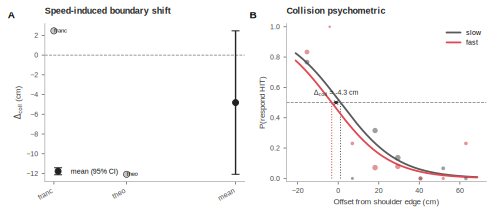

In [8]:
r_h3 = h3.run(t)

## H4. Test-retest reliability

H4 produces the **SDC** for Delta_PPS, which is the noise floor H6b needs. In the
old notebook this passed silently through a global variable. Now it is an
explicit hand-off, so you cannot run H6b without H4 by accident.

In [ ]:
r_h4 = h4.run(t)

t.sdc_delta_pps = r_h4["SDC_DELTA_PPS"]
print(f"\nnoise floor carried forward to H6b: {t.sdc_delta_pps}")

# Aim 2 — PPS and its recalibration in Parkinson's disease

These need one patient and one matched control. Without them each cell prints
that it is skipped and returns `{"skipped": True}`, so the notebook still runs
top to bottom on pilot data.

## H5. Does the patient show distance-dependent facilitation at all?

Patient:         pam
Matched control: franc

Patient PPS sessions available: [np.int64(1)]

H5: near-far index in the patient, tested against a shuffled-distance null

 session  n_usable_trials  observed_nearfar_ms  permutation_p  n_permutations  supported
       1                0                  NaN            NaN               0      False

  H5 is NOT supported in every session.
  saved: figures/h5_patient_nearfar.svg
  saved: figures/h5_patient_nearfar.pdf


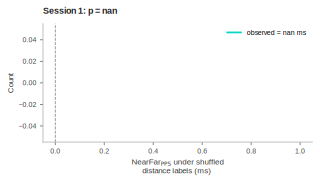

In [9]:
r_h5 = h5.run(t)

## H6. Is the patient's speed recalibration altered?

Two tests, and the second is **gated** on the first. If the patient shows no
recalibration signal at all (Test A), comparing their Delta_PPS to a control's
would just be comparing noise, so Test B is not run.

H6 also chooses which patient session to use. **H7 and H8b both depend on that
choice**, so it is handed over explicitly below.

  Falling back to session 1, which may NOT be the

Patient session (high dopamine): 1
Control session:                 1

Patient Delta_PPS = nan
Control Delta_PPS = 0.417
Observed D_PPS    = nan   (patient minus control)

--- Test A: does the patient show any Delta_PPS? ---
  observed Delta_PPS = nan
  permutation p      = nan
  Test A supported   = False

Test A did not pass, so Test B is NOT run.
  Without a recalibration signal in the patient, comparing their
  Delta_PPS to the control's would just be comparing noise.
  saved: figures/h6_patient_recalibration.svg
  saved: figures/h6_patient_recalibration.pdf


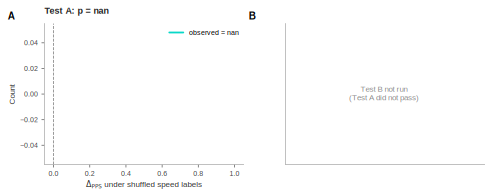


sessions carried forward: patient=1, control=1


In [10]:
r_h6 = h6.run(t)

t.patient_session = r_h6.get("PATIENT_SESSION_USED")
t.control_session = r_h6.get("CONTROL_SESSION_USED", 1)
print(f"\nsessions carried forward: patient={t.patient_session}, control={t.control_session}")

## H6b. Does dopamine modulate the recalibration? (exploratory)

Requires the bootstrap to be consistent in sign **and** the effect to be bigger
than the H4 noise floor. A tight bootstrap on an unreliable measure is not
evidence.

In [ ]:
r_h6b = h6b.run(t)

## H7. Is the patient's collision-boundary shift altered?

In [ ]:
r_h7 = h7.run(t)

# Aim 3 — PPS plasticity and Hit-or-Miss judgment

## H8a. Across young controls

Exact permutation Spearman correlations. Be honest about power: at n = 5, a
one-sided exact p < 0.05 needs rho >= 0.9. A null result here means "we could not
have detected anything short of a near-perfect relationship", not "there is no
relationship".

In [ ]:
r_h8a = h8a.run(t)

## H8b. In the patient-control pair

Uses a **joint sign criterion**, not two separate tests. Two measures can each be
negative 96% of the time while being negative *together* only 60% of the time.
Since the claim is a co-occurrence, we measure the co-occurrence directly.

This needs H6's bootstrap, paired on the bootstrap index, which is why `r_h6` is
passed in rather than recomputed.

In [ ]:
r_h8b = h8b.run(t, r_h6)

## Summary

In [ ]:
summary = pd.DataFrame([
    {"hypothesis": "H1",  "outcome": r_h1["supported"]},
    {"hypothesis": "H1a", "outcome": f"{r_h1a['n_supported']}/{r_h1a['n_total']} participants"},
    {"hypothesis": "H2",  "outcome": r_h2["supported"]},
    {"hypothesis": "H3",  "outcome": r_h3["supported"]},
    {"hypothesis": "H5",  "outcome": r_h5.get("h5_supported_overall", "skipped")},
    {"hypothesis": "H6",  "outcome": r_h6.get("h6_classification", "skipped")},
    {"hypothesis": "H6b", "outcome": r_h6b.get("h6b_classification", "skipped")},
    {"hypothesis": "H7",  "outcome": r_h7.get("h7_classification", "skipped")},
    {"hypothesis": "H8a.1", "outcome": r_h8a["h8a_1"]["supported"]},
    {"hypothesis": "H8a.2", "outcome": r_h8a["h8a_2_near"]["supported"]},
    {"hypothesis": "H8a.3", "outcome": r_h8a["h8a_3"]["supported"]},
])
summary